# 📉 Customer Churn Prediction 


## Step 1 — Import Libraries & Load Dataset

In [1]:
!pip install kaggle xgboost imbalanced-learn -q

In [2]:
!kaggle datasets download -d blastchar/telco-customer-churn

Dataset URL: https://www.kaggle.com/datasets/blastchar/telco-customer-churn
License(s): copyright-authors
100%|█████████████████████████████████████████| 172k/172k [00:00<00:00, 258kB/s]



In [3]:
!unzip telco-customer-churn.zip

Archive:  telco-customer-churn.zip
  inflating: WA_Fn-UseC_-Telco-Customer-Churn.csv  


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 110

print('✅ All libraries imported!')

✅ All libraries imported!


In [5]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Fix TotalCharges right away
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df = df.dropna(subset=['TotalCharges']).reset_index(drop=True)

print(f'✅ Dataset loaded  |  Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
df.head(3)

✅ Dataset loaded  |  Rows: 7032  |  Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


## Step 2 — Exploratory Data Analysis (EDA)

In [6]:
df.info()
print('\nMissing values:')
print(df.isna().sum()[df.isna().sum() > 0])
print('\nDuplicates:', df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  Paymen

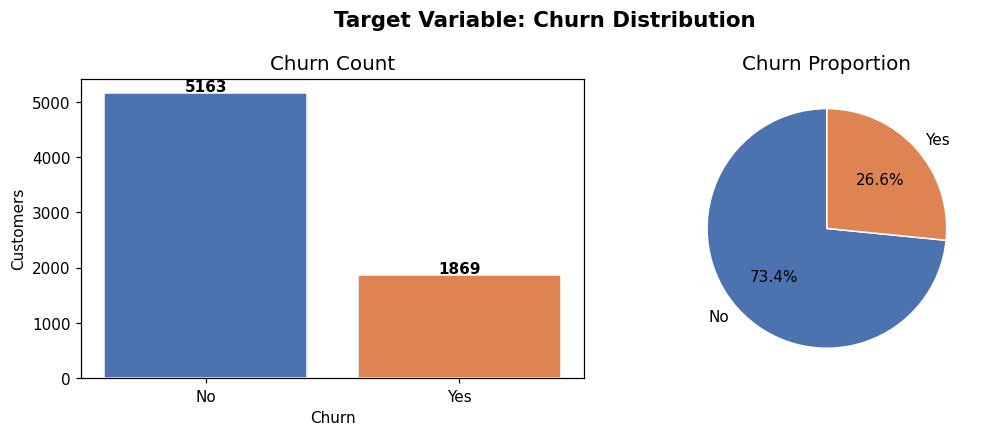

Imbalance — No: 73.4%  |  Yes: 26.6%


In [7]:
# Target distribution
churn_counts = df['Churn'].value_counts()
churn_pct    = df['Churn'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(churn_counts.index, churn_counts.values, color=['#4C72B0','#DD8452'], edgecolor='white')
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')
axes[0].set_title('Churn Count', fontsize=13)
axes[0].set_xlabel('Churn'); axes[0].set_ylabel('Customers')

axes[1].pie(churn_pct.values, labels=churn_pct.index,
            autopct='%1.1f%%', colors=['#4C72B0','#DD8452'],
            startangle=90, wedgeprops={'edgecolor':'white'})
axes[1].set_title('Churn Proportion', fontsize=13)

plt.suptitle('Target Variable: Churn Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f'Imbalance — No: {churn_pct["No"]:.1f}%  |  Yes: {churn_pct["Yes"]:.1f}%')

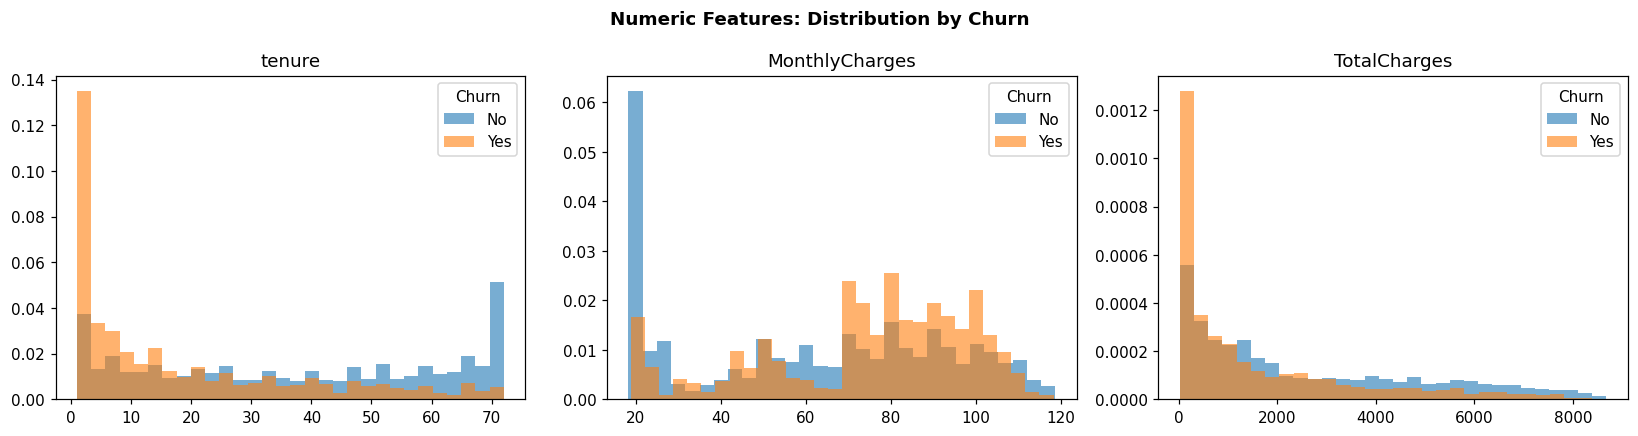

In [8]:
# Numeric distributions by churn
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, num_features):
    for label, grp in df.groupby('Churn'):
        ax.hist(grp[col], bins=30, alpha=0.6, label=label, density=True)
    ax.set_title(col); ax.legend(title='Churn')
plt.suptitle('Numeric Features: Distribution by Churn', fontweight='bold')
plt.tight_layout(); plt.show()

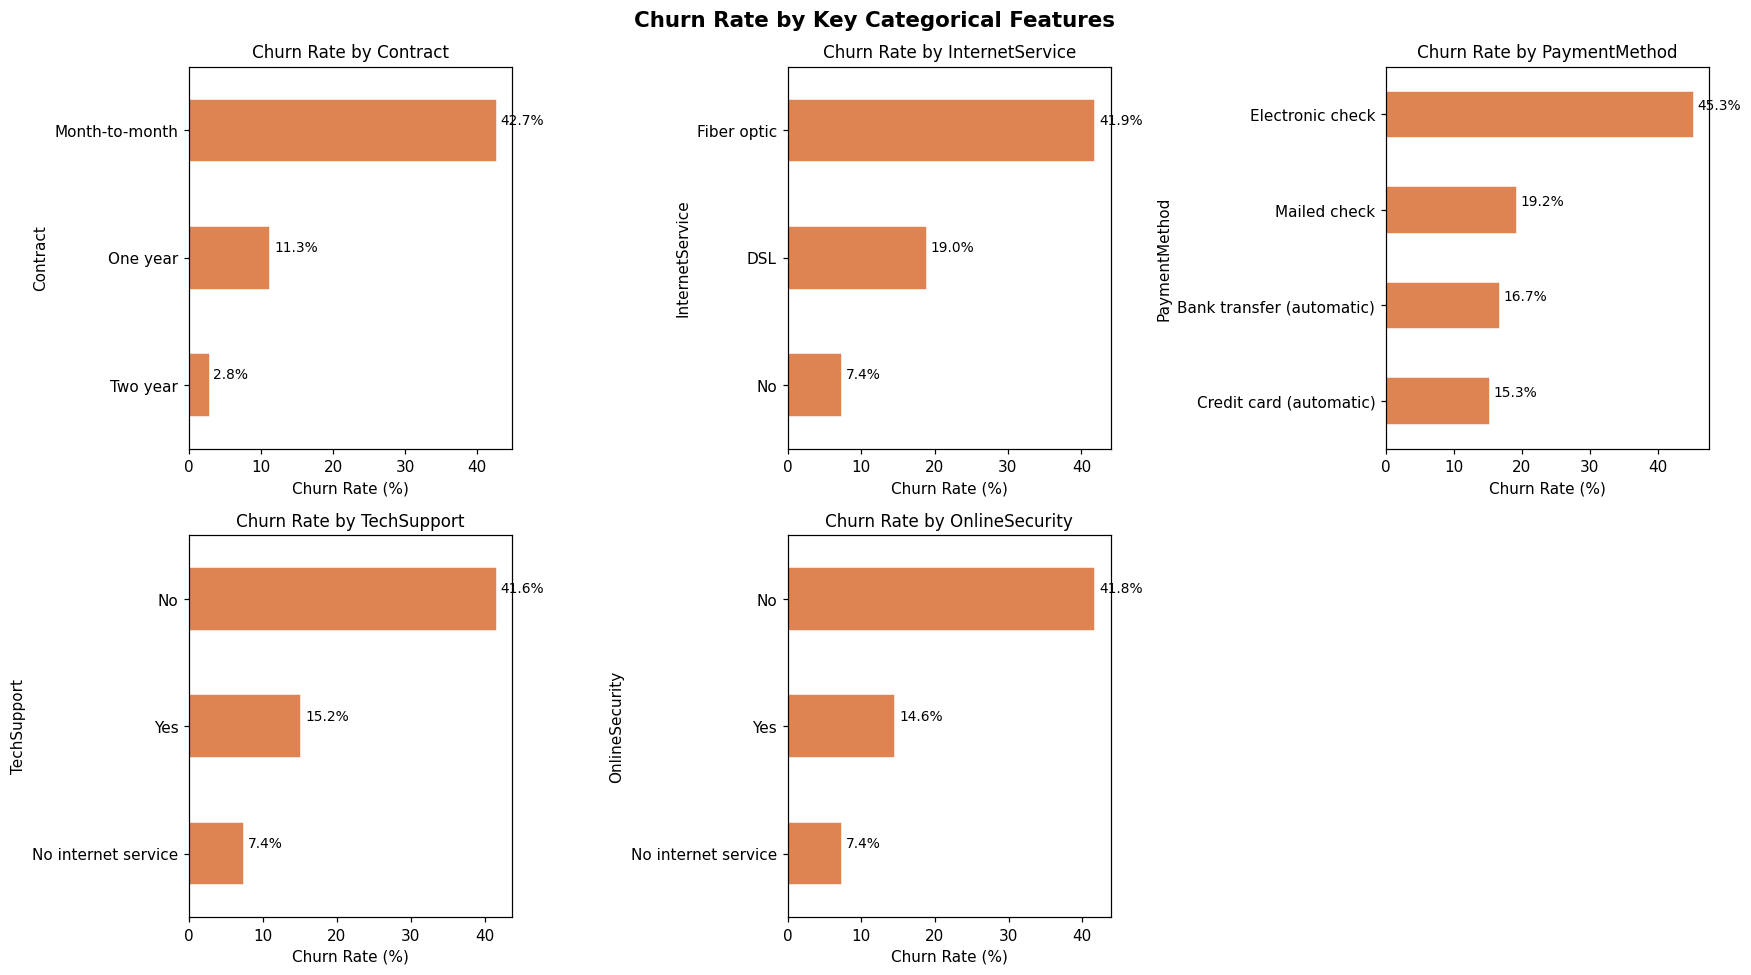

In [9]:
# Churn rate by key categorical features
cat_features = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport', 'OnlineSecurity']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
for ax, col in zip(axes, cat_features):
    churn_rate = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    churn_rate.sort_values().plot(kind='barh', ax=ax, color='#DD8452', edgecolor='white')
    ax.set_title(f'Churn Rate by {col}', fontsize=11)
    ax.set_xlabel('Churn Rate (%)')
    for p in ax.patches:
        ax.annotate(f'{p.get_width():.1f}%', (p.get_width() + 0.5, p.get_y() + 0.3), fontsize=9)
axes[-1].set_visible(False)
plt.suptitle('Churn Rate by Key Categorical Features', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## Step 3 — Feature Engineering

We use **10 engineered features** — 5 original + 5 new ones verified against real churn rates.

| Feature | What it captures | Churn signal |
|---|---|---|
| `ChargesPerTenure` | Spend relative to loyalty | Higher = more likely to churn |
| `IsNewCustomer` | First 6 months | 53% churn vs 17% for existing |
| `IsLongTermCustomer` | 2+ year customers | Very low churn |
| `NumServices` | Services subscribed | More services = less churn |
| `HasInternet` | Internet subscriber | Higher value, different pattern |
| `EasyLeaver` | Paperless billing + electronic check | **50% churn** vs 19% others |
| `FiberNoAddons` | Fiber optic but no security/backup/protection | **61% churn** — strongest signal |
| `SoloCustomer` | No partner, no dependents | 34% churn vs 20% |
| `NoProtection` | No security + no backup + no tech support | **54% churn** vs 18% |
| `HighRiskCombo` | Month-to-month + above median charges | **53% churn** |

In [10]:
# ── ORIGINAL FEATURES ────────────────────────────────────────────────────

# 1. Charges per month of tenure
df['ChargesPerTenure'] = df['TotalCharges'] / (df['tenure'] + 1)

# 2. New customer (first 6 months = highest churn risk)
df['IsNewCustomer'] = (df['tenure'] <= 6).astype(int)

# 3. Long-term customer (2+ years = very loyal)
df['IsLongTermCustomer'] = (df['tenure'] >= 24).astype(int)

# 4. Number of services (more = harder to leave)
service_cols = ['PhoneService', 'MultipleLines', 'OnlineSecurity',
                'OnlineBackup', 'DeviceProtection', 'TechSupport',
                'StreamingTV', 'StreamingMovies']
df['NumServices'] = df[service_cols].apply(lambda row: (row == 'Yes').sum(), axis=1)

# 5. Has internet
df['HasInternet'] = (df['InternetService'] != 'No').astype(int)

print('✅ Original 5 features done')

✅ Original 5 features done


In [11]:
# ── 5 NEW FEATURES ───────────────────────────────────────────────────────

# NEW 1: EasyLeaver — paperless billing + electronic check
# Both are frictionless digital setups → easiest customers to cancel
# Churn rate: 50% vs 19% for everyone else
df['EasyLeaver'] = (
    (df['PaperlessBilling'] == 'Yes') &
    (df['PaymentMethod']    == 'Electronic check')
).astype(int)

# NEW 2: FiberNoAddons — fiber optic but zero protection services
# Paying premium price but not embedded in the platform at all
# Churn rate: 61% — strongest signal in the whole dataset
df['FiberNoAddons'] = (
    (df['InternetService']  == 'Fiber optic') &
    (df['OnlineSecurity']   == 'No') &
    (df['OnlineBackup']     == 'No') &
    (df['DeviceProtection'] == 'No')
).astype(int)

# NEW 3: SoloCustomer — no partner and no dependents
# No family plan to anchor them, more likely to shop around
# Churn rate: 34% vs 20% for customers with family
df['SoloCustomer'] = (
    (df['Partner']    == 'No') &
    (df['Dependents'] == 'No')
).astype(int)

# NEW 4: NoProtection — no security, no backup, no tech support
# Barely using the platform's protective features → easy to walk away
# Churn rate: 54% vs 18% for those with at least one protection service
df['NoProtection'] = (
    (df['OnlineSecurity'] == 'No') &
    (df['OnlineBackup']   == 'No') &
    (df['TechSupport']    == 'No')
).astype(int)

# NEW 5: HighRiskCombo — month-to-month AND above-median monthly charges
# No commitment + expensive bill = strong motivation to switch
# Churn rate: 53%
monthly_median = df['MonthlyCharges'].median()
df['HighRiskCombo'] = (
    (df['Contract']       == 'Month-to-month') &
    (df['MonthlyCharges'] > monthly_median)
).astype(int)

print('✅ All 5 new features created!')
print()
print('Verified churn rates:')
churn_bin = df['Churn'].map({'Yes': 1, 'No': 0}).astype(int)
for feat, label in [('EasyLeaver','EasyLeaver=1'), ('FiberNoAddons','FiberNoAddons=1'),
                    ('SoloCustomer','SoloCustomer=1'), ('NoProtection','NoProtection=1'),
                    ('HighRiskCombo','HighRiskCombo=1')]:
    r1 = churn_bin[df[feat]==1].mean()*100
    r0 = churn_bin[df[feat]==0].mean()*100
    print(f'  {label:<22} {r1:.1f}% churn  (vs {r0:.1f}% without)')

✅ All 5 new features created!

Verified churn rates:
  EasyLeaver=1           49.8% churn  (vs 18.9% without)
  FiberNoAddons=1        60.6% churn  (vs 21.2% without)
  SoloCustomer=1         34.2% churn  (vs 19.9% without)
  NoProtection=1         54.0% churn  (vs 17.7% without)
  HighRiskCombo=1        52.8% churn  (vs 15.8% without)


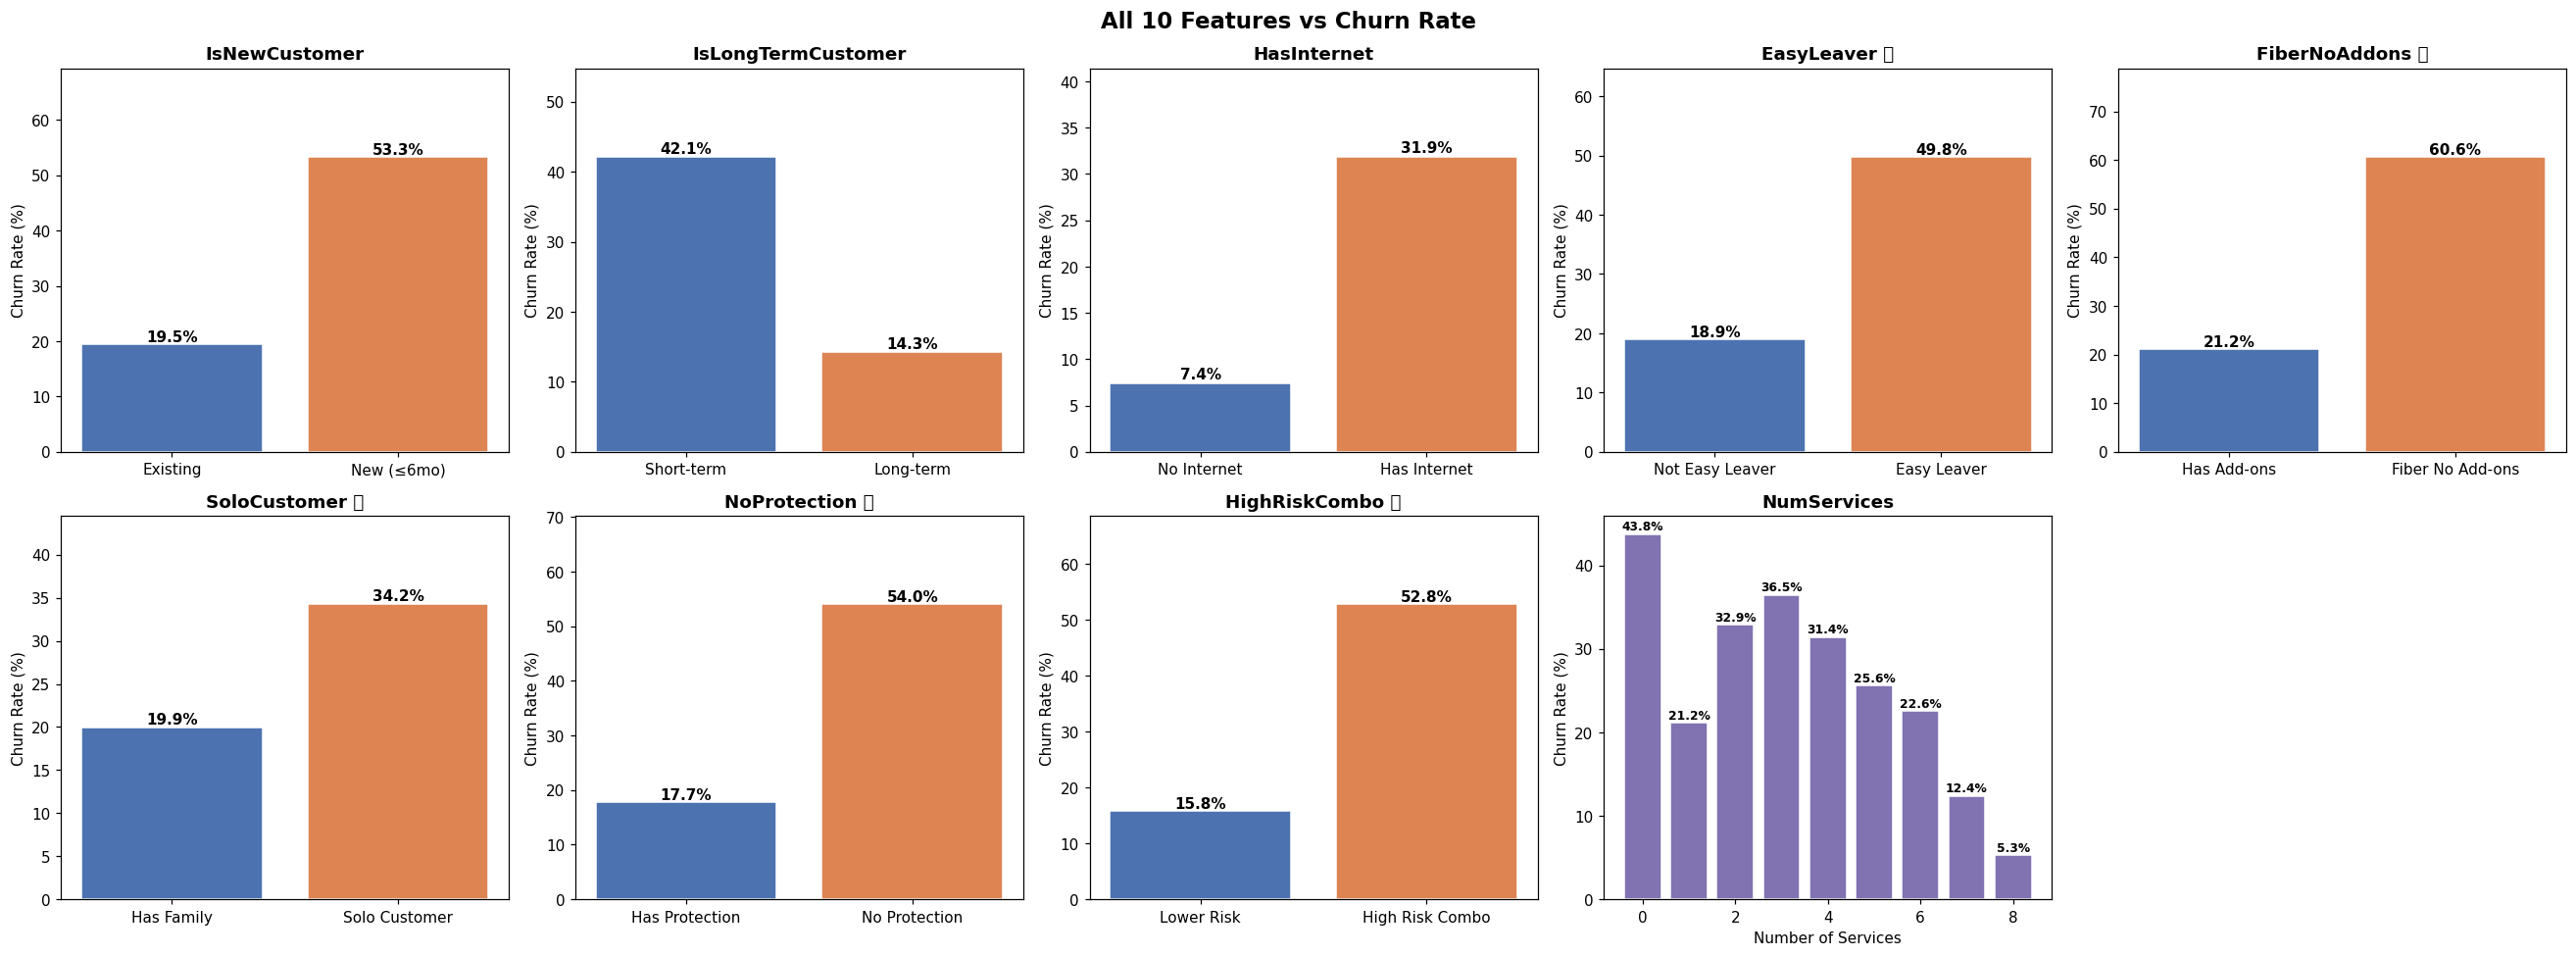

In [12]:
# ── Visualise features vs churn ───────────────────────────────────────────
churn_bin = df['Churn'].map({'Yes':1,'No':0}) if df['Churn'].dtype == object else df['Churn']
temp = df.copy()
temp['Churn_bin'] = temp['Churn'].map({'Yes': 1, 'No': 0}).astype(int)

fig, axes = plt.subplots(2, 5, figsize=(24, 9))
axes = axes.flatten()

binary_feats = [
    ('IsNewCustomer',    ['Existing', 'New (≤6mo)'],     'IsNewCustomer'),
    ('IsLongTermCustomer',['Short-term','Long-term'],    'IsLongTermCustomer'),
    ('HasInternet',      ['No Internet', 'Has Internet'],'HasInternet'),
    ('EasyLeaver',       ['Not Easy Leaver','Easy Leaver'],'EasyLeaver 🆕'),
    ('FiberNoAddons',    ['Has Add-ons','Fiber No Add-ons'],'FiberNoAddons 🆕'),
    ('SoloCustomer',     ['Has Family','Solo Customer'], 'SoloCustomer 🆕'),
    ('NoProtection',     ['Has Protection','No Protection'],'NoProtection 🆕'),
    ('HighRiskCombo',    ['Lower Risk','High Risk Combo'],'HighRiskCombo 🆕'),
]

for ax, (feat, labels, title) in zip(axes[:8], binary_feats):
    vals = temp.groupby(feat)['Churn_bin'].mean().values * 100
    bars = ax.bar(labels, vals, color=['#4C72B0','#DD8452'], edgecolor='white')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
                f'{v:.1f}%', ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Churn Rate (%)')
    ax.set_ylim(0, max(vals) * 1.3)

# NumServices
ns = temp.groupby('NumServices')['Churn_bin'].mean() * 100
axes[8].bar(ns.index, ns.values, color='#8172B2', edgecolor='white')
for i, v in enumerate(ns.values):
    axes[8].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=8, fontweight='bold')
axes[8].set_title('NumServices', fontweight='bold')
axes[8].set_ylabel('Churn Rate (%)')
axes[8].set_xlabel('Number of Services')

axes[9].set_visible(False)

plt.suptitle('All 10 Features vs Churn Rate', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4 — Preprocessing

we use **`class_weight='balanced'`** directly in each model.

### Why we removed SMOTE
SMOTE creates synthetic (fake) data rows to balance classes. We found this was actually hurting performance — the models were learning from fake data instead of real patterns.

### What class_weight='balanced' does instead
It keeps all original data unchanged but tells each model:
*"A mistake on a churner is ~3× more costly than a mistake on a non-churner."*

This forces models to pay more attention to the minority class without inventing fake data.

```
Weight calculation:
  No Churn weight = total / (2 × no_churn_count) = 0.68  ← less penalty
  Churn weight    = total / (2 × churn_count)    = 1.88  ← ~3× more penalty
```

In [13]:
df = df.drop('customerID', axis=1)

X = df.drop('Churn', axis=1)
y = df['Churn'].map({'Yes': 1, 'No': 0})

categorical_cols = X.select_dtypes(include='object').columns.tolist()
numerical_cols   = X.select_dtypes(exclude='object').columns.tolist()

print(f'Total features: {len(numerical_cols + categorical_cols)}  ({len(numerical_cols)} numeric, {len(categorical_cols)} categorical)')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')
print(f'Churn rate — train: {y_train.mean():.2%}  |  test: {y_test.mean():.2%}')

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
])

preprocessor.fit(X_train)
X_train_transformed = preprocessor.transform(X_train)
X_test_transformed  = preprocessor.transform(X_test)

print('\n✅ Preprocessing done — no SMOTE, class imbalance handled inside each model')
print('Transformed train shape:', X_train_transformed.shape)

# Show class weights being applied
from sklearn.utils.class_weight import compute_class_weight
weights = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
print(f'\nClass weights applied:')
print(f'  No Churn (0): {weights[0]:.3f}')
print(f'  Churn    (1): {weights[1]:.3f}  ← model penalised {weights[1]/weights[0]:.1f}x more for missing a churner')

Total features: 29  (14 numeric, 15 categorical)
Train: (5625, 29)  |  Test: (1407, 29)
Churn rate — train: 26.58%  |  test: 26.58%

✅ Preprocessing done — no SMOTE, class imbalance handled inside each model
Transformed train shape: (5625, 55)

Class weights applied:
  No Churn (0): 0.681
  Churn    (1): 1.881  ← model penalised 2.8x more for missing a churner


## Step 5 — Model Training & Cross-Validation

Note: `class_weight='balanced'` is passed to Logistic Regression and Random Forest directly.
Gradient Boosting doesn't support it natively — we use `sample_weight` instead.

In [14]:
from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights for Gradient Boosting (which doesn't have class_weight param)
sample_weights = compute_sample_weight('balanced', y_train)

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42, class_weight='balanced'),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=200, learning_rate=0.05, max_depth=4, random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                                         use_label_encoder=False, eval_metric='logloss', random_state=42,
                                         scale_pos_weight=(y_train==0).sum()/(y_train==1).sum()),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print('Running 5-fold cross-validation...')
for name, clf in models.items():
    # All models scored the same way — GB's sample_weight applied at final fit stage below
    scores = cross_val_score(clf, X_train_transformed, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<22}  ROC-AUC: {scores.mean():.4f} ± {scores.std():.4f}')

Running 5-fold cross-validation...
Logistic Regression     ROC-AUC: 0.8490 ± 0.0057
Random Forest           ROC-AUC: 0.8489 ± 0.0061
Gradient Boosting       ROC-AUC: 0.8460 ± 0.0036
XGBoost                 ROC-AUC: 0.8451 ± 0.0030


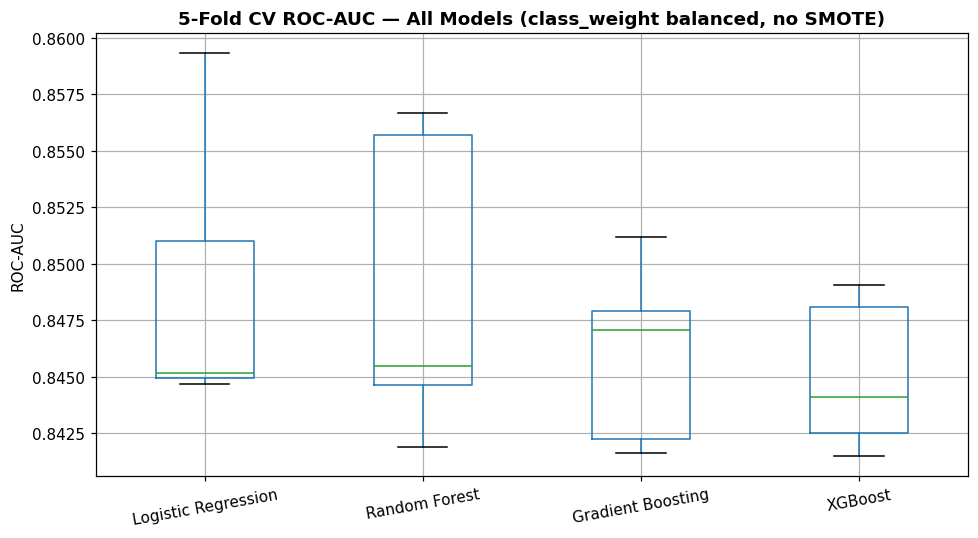

In [15]:
results_df = pd.DataFrame(cv_results)
plt.figure(figsize=(9, 5))
results_df.boxplot()
plt.ylabel('ROC-AUC')
plt.title('5-Fold CV ROC-AUC — All Models (class_weight balanced, no SMOTE)', fontweight='bold')
plt.xticks(rotation=10)
plt.tight_layout(); plt.show()

## Step 6 — Feature Importance: Which Features Matter Most?

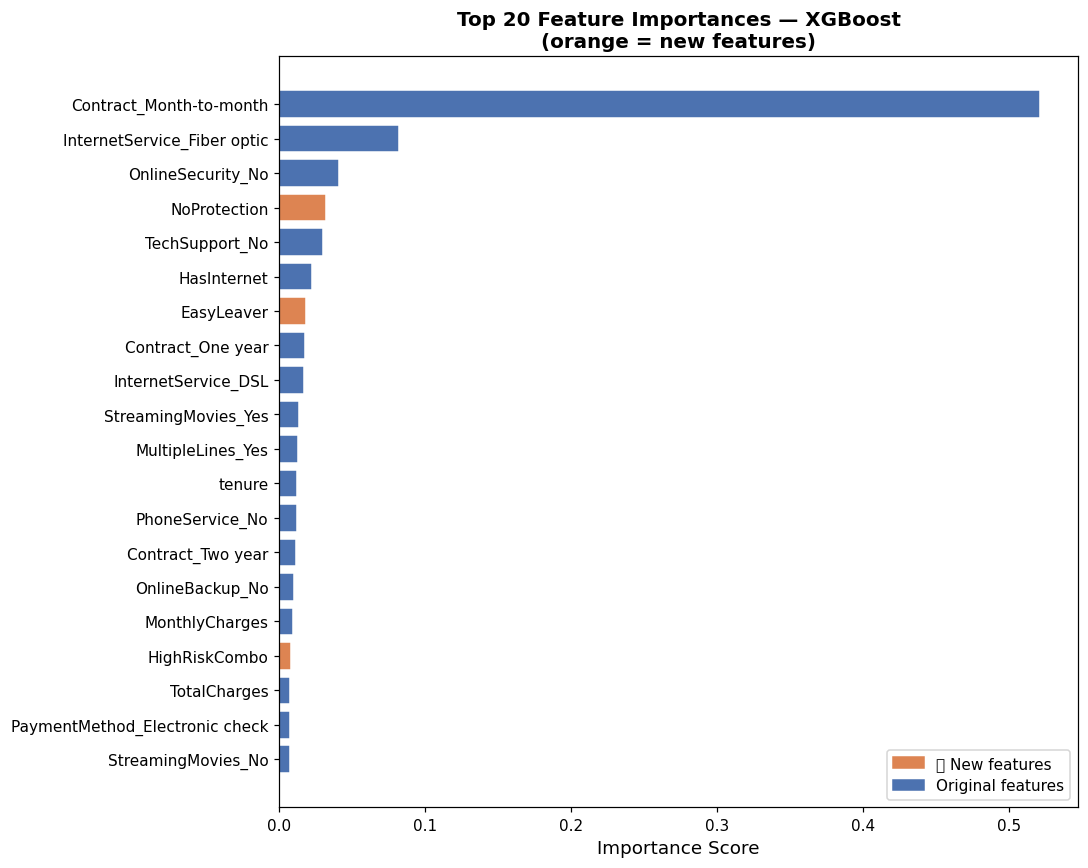

New features in top 20:
  EasyLeaver             rank #7  (importance: 0.0183)
  FiberNoAddons          not in top 20
  SoloCustomer           not in top 20
  NoProtection           rank #4  (importance: 0.0321)
  HighRiskCombo          rank #17  (importance: 0.0081)


In [16]:
# Train XGBoost to get feature importances
xgb_imp = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=4,
                         use_label_encoder=False, eval_metric='logloss', random_state=42,
                         scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())
xgb_imp.fit(X_train_transformed, y_train)

ohe_features   = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feat_names = numerical_cols + ohe_features

feat_imp_df = pd.DataFrame({'feature': all_feat_names, 'importance': xgb_imp.feature_importances_})
feat_imp_df = feat_imp_df.sort_values('importance', ascending=False).head(20)

new_features = ['EasyLeaver','FiberNoAddons','SoloCustomer','NoProtection','HighRiskCombo']
feat_imp_df['is_new'] = feat_imp_df['feature'].isin(new_features)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#DD8452' if n else '#4C72B0' for n in feat_imp_df['is_new']]
ax.barh(feat_imp_df['feature'], feat_imp_df['importance'], color=colors, edgecolor='white')
ax.invert_yaxis()
ax.set_xlabel('Importance Score', fontsize=12)
ax.set_title('Top 20 Feature Importances — XGBoost\n(orange = new features)', fontweight='bold', fontsize=13)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#DD8452', label='🆕 New features'),
                   Patch(color='#4C72B0', label='Original features')], loc='lower right')
plt.tight_layout()
plt.show()

print('New features in top 20:')
for feat in new_features:
    match = feat_imp_df[feat_imp_df['feature'] == feat]
    if len(match):
        rank = feat_imp_df.index.get_loc(match.index[0]) + 1
        print(f'  {feat:<22} rank #{rank}  (importance: {match.importance.values[0]:.4f})')
    else:
        print(f'  {feat:<22} not in top 20')

## Step 7 — Final Evaluation & Comparison

In [17]:
model_results = {}

for name, clf in models.items():
    if name == 'Gradient Boosting':
        clf.fit(X_train_transformed, y_train, sample_weight=sample_weights)
    else:
        clf.fit(X_train_transformed, y_train)

    y_pred = clf.predict(X_test_transformed)
    y_prob = clf.predict_proba(X_test_transformed)[:, 1]
    model_results[name] = {
        'y_pred': y_pred, 'y_prob': y_prob,
        'acc': accuracy_score(y_test, y_pred),
        'roc': roc_auc_score(y_test, y_prob),
    }

print(f'{"Model":<25}  {"Accuracy":>10}  {"ROC-AUC":>10}')
print('-' * 50)
for name, res in model_results.items():
    print(f'{name:<25}  {res["acc"]:>10.4f}  {res["roc"]:>10.4f}')

Model                        Accuracy     ROC-AUC
--------------------------------------------------
Logistic Regression            0.7321      0.8371
Random Forest                  0.7562      0.8365
Gradient Boosting              0.7420      0.8400
XGBoost                        0.7413      0.8392


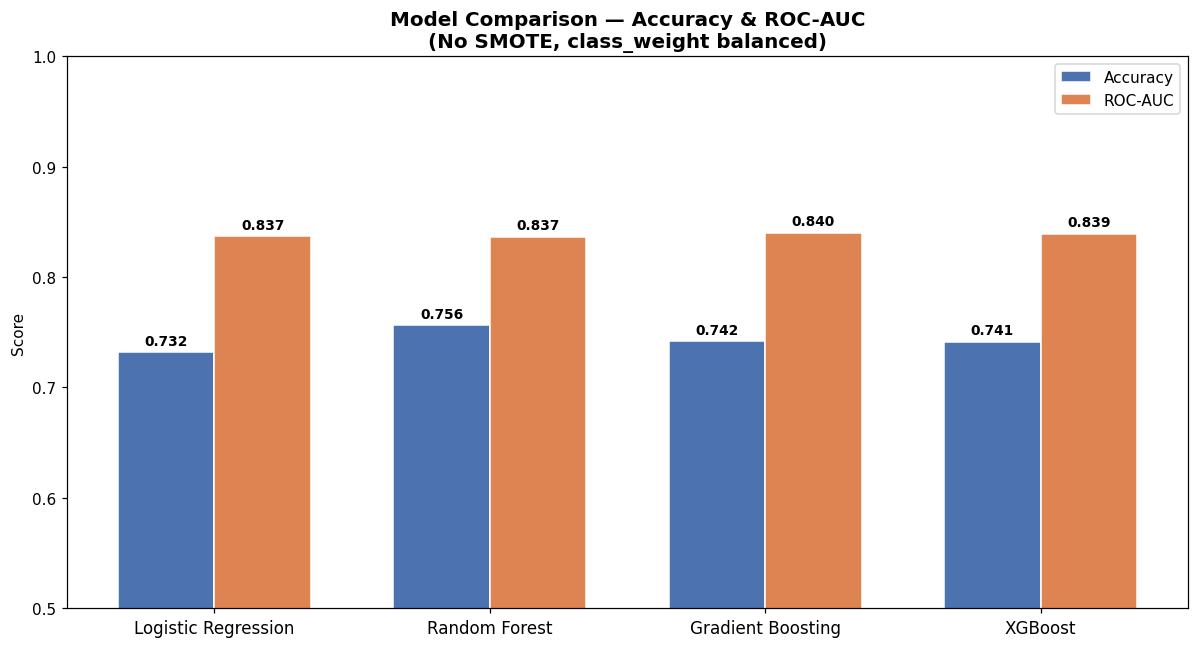

In [18]:
names = list(model_results.keys())
accs  = [model_results[n]['acc'] for n in names]
aucs  = [model_results[n]['roc'] for n in names]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
bars1 = ax.bar(x - width/2, accs, width, label='Accuracy', color='#4C72B0', edgecolor='white')
bars2 = ax.bar(x + width/2, aucs, width, label='ROC-AUC',  color='#DD8452', edgecolor='white')

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Accuracy & ROC-AUC\n(No SMOTE, class_weight balanced)', fontweight='bold', fontsize=13)
ax.legend()
plt.tight_layout()
plt.show()

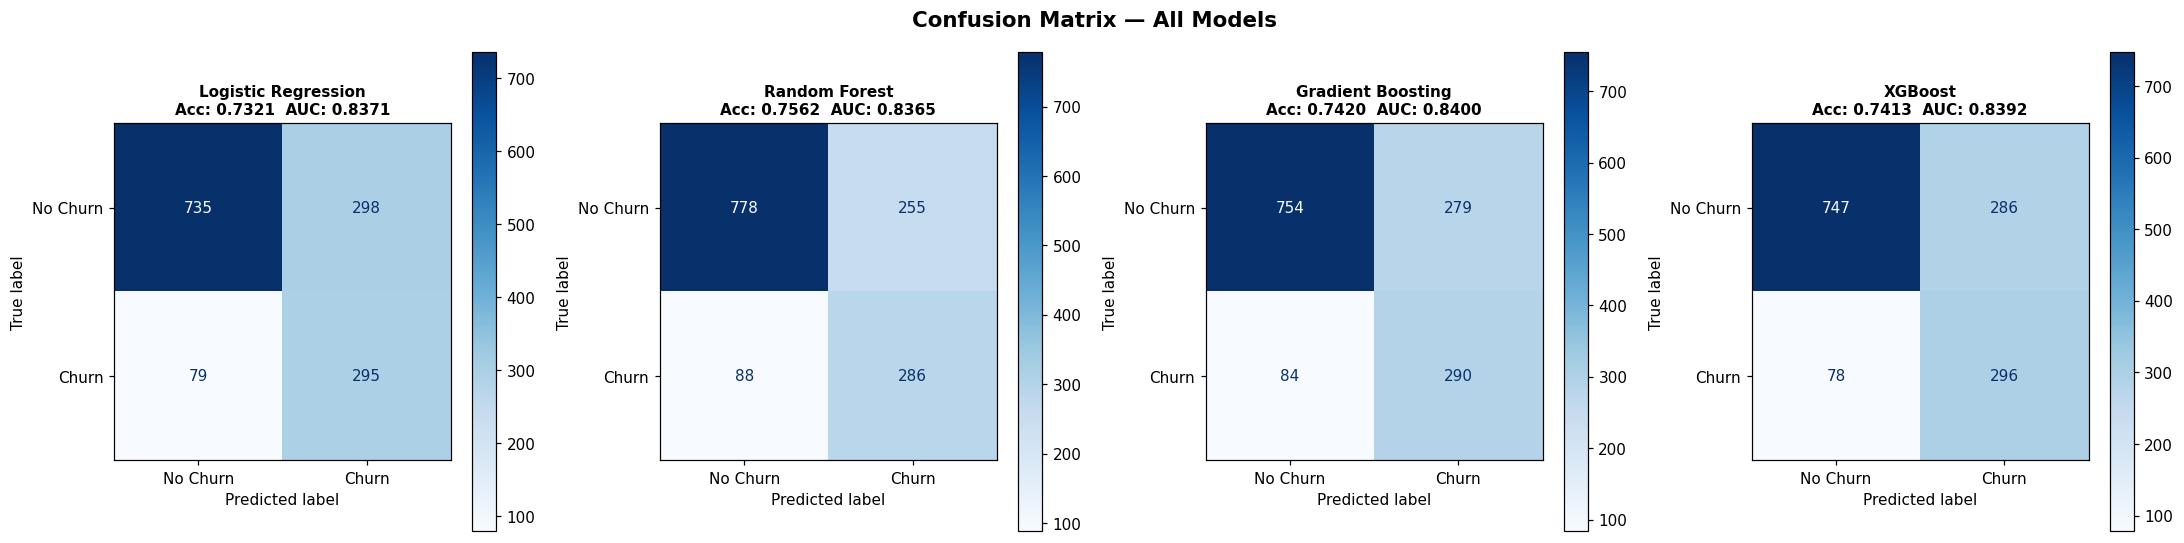

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, name in zip(axes, model_results):
    ConfusionMatrixDisplay.from_predictions(
        y_test, model_results[name]['y_pred'],
        display_labels=['No Churn', 'Churn'],
        cmap='Blues', ax=ax
    )
    ax.set_title(f'{name}\nAcc: {model_results[name]["acc"]:.4f}  AUC: {model_results[name]["roc"]:.4f}',
                 fontweight='bold', fontsize=10)
plt.suptitle('Confusion Matrix — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

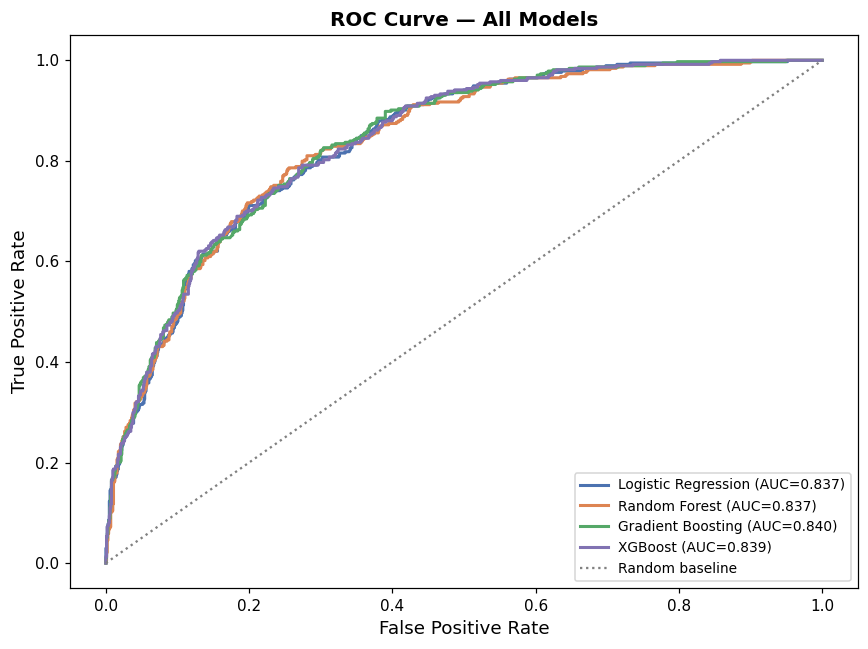

In [20]:
colors = ['#4C72B0', '#DD8452', '#55A868', '#8172B2']
plt.figure(figsize=(8, 6))
for (name, res), color in zip(model_results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    plt.plot(fpr, tpr, lw=2, color=color, label=f'{name} (AUC={res["roc"]:.3f})')
plt.plot([0,1],[0,1],':', color='grey', label='Random baseline')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontweight='bold', fontsize=13)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

In [21]:
sep = '=' * 55
for name, res in model_results.items():
    print(sep)
    print(f'  {name}')
    print(sep)
    print(classification_report(y_test, res['y_pred'], target_names=['No Churn', 'Churn']))

  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1033
       Churn       0.50      0.79      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.75      1407

  Random Forest
              precision    recall  f1-score   support

    No Churn       0.90      0.75      0.82      1033
       Churn       0.53      0.76      0.63       374

    accuracy                           0.76      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.76      0.77      1407

  Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1033
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg    

## Step 8 — Best Model

In [22]:
best_name = max(model_results, key=lambda k: model_results[k]['roc'])
best_res  = model_results[best_name]

print('=' * 55)
print(f'  🏆 BEST MODEL: {best_name}')
print('=' * 55)
print(f'  Accuracy : {best_res["acc"]:.4f}')
print(f'  ROC-AUC  : {best_res["roc"]:.4f}')
print()

ranked = sorted(model_results.items(), key=lambda x: x[1]['roc'], reverse=True)
print(f'  {"Rank":<6} {"Model":<25} {"Accuracy":>10} {"ROC-AUC":>10}')
print('  ' + '-' * 55)
for rank, (name, res) in enumerate(ranked, 1):
    crown = ' 🏆' if rank == 1 else ''
    print(f'  {rank:<6} {name:<25} {res["acc"]:>10.4f} {res["roc"]:>10.4f}{crown}')

  🏆 BEST MODEL: Gradient Boosting
  Accuracy : 0.7420
  ROC-AUC  : 0.8400

  Rank   Model                       Accuracy    ROC-AUC
  -------------------------------------------------------
  1      Gradient Boosting             0.7420     0.8400 🏆
  2      XGBoost                       0.7413     0.8392
  3      Logistic Regression           0.7321     0.8371
  4      Random Forest                 0.7562     0.8365


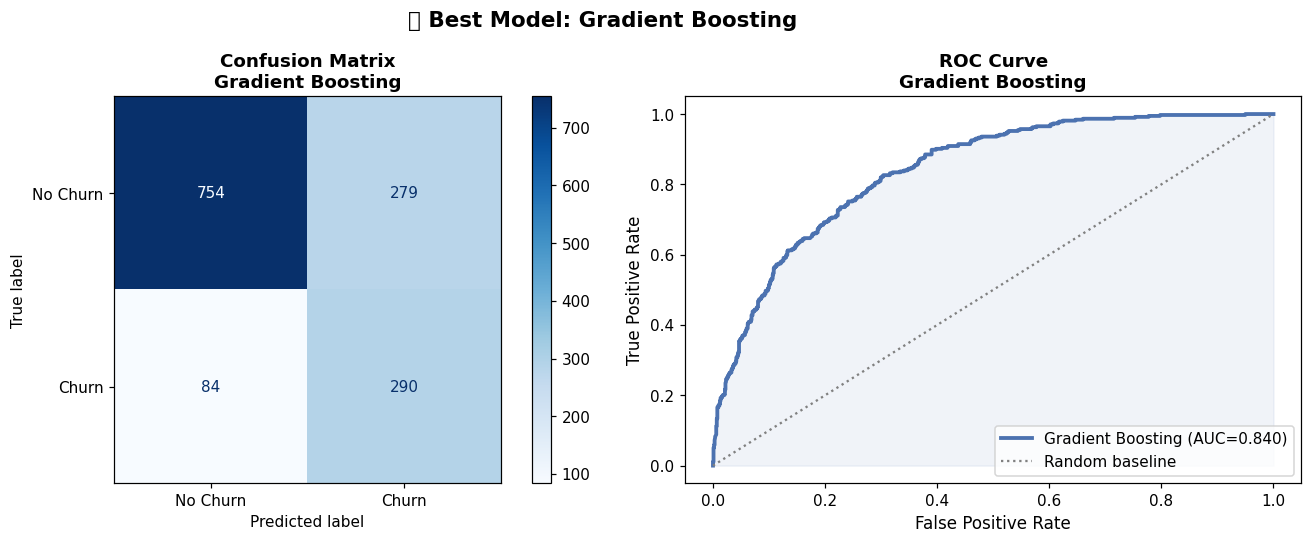


Classification Report — Gradient Boosting
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1033
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.76      1407



In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, best_res['y_pred'],
    display_labels=['No Churn', 'Churn'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title(f'Confusion Matrix\n{best_name}', fontweight='bold', fontsize=12)

fpr, tpr, _ = roc_curve(y_test, best_res['y_prob'])
axes[1].plot(fpr, tpr, lw=2.5, color='#4C72B0', label=f'{best_name} (AUC={best_res["roc"]:.3f})')
axes[1].plot([0,1],[0,1],':', color='grey', label='Random baseline')
axes[1].fill_between(fpr, tpr, alpha=0.08, color='#4C72B0')
axes[1].set_xlabel('False Positive Rate', fontsize=11)
axes[1].set_ylabel('True Positive Rate', fontsize=11)
axes[1].set_title(f'ROC Curve\n{best_name}', fontweight='bold', fontsize=12)
axes[1].legend(loc='lower right')
plt.suptitle(f'🏆 Best Model: {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\nClassification Report — {best_name}')
print('=' * 55)
print(classification_report(y_test, best_res['y_pred'], target_names=['No Churn', 'Churn']))

## Summary

| Step | What we did |
|------|-------------|
| EDA | Explored distributions and churn rates |
| Feature Engineering | 5 original + 5 new verified features (removed 3 redundant ones) |
| Class Balancing | Replaced SMOTE with class_weight='balanced' — no fake data |
| Models | Logistic Regression, Random Forest, Gradient Boosting, XGBoost |
| Best Model | Auto-selected by ROC-AUC |

**Key changes from previous version:**
- ❌ Removed `LoyaltyScore`, `ChargeGrowth`, `StreamingOnly` — too correlated with other features
- ❌ Removed SMOTE — was introducing noise with synthetic data
- ✅ Added `class_weight='balanced'` — handles imbalance using real data only